# IPM Caribe — Pipeline completo
Análisis del Índice de Pobreza Multidimensional en la región Caribe de Colombia (2018-2024) con predicción para 2025.

In [166]:
# ==============================
# 1. LIBRERÍAS
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import unicodedata
import json

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor
)
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.dummy import DummyRegressor
from sklearn.svm import SVR
from catboost import CatBoostRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

## Funciones auxiliares

In [167]:
# ==============================
# 2. FUNCIONES AUXILIARES
# ==============================

def weighted_mean(x, value, weight):
    """Media ponderada de `value` usando `weight` como pesos."""
    return (x[value] * x[weight]).sum() / x[weight].sum()


def limpiar_texto(texto):
    """Normaliza texto: mayúsculas, sin tildes ni espacios extra."""
    if pd.isna(texto):
        return texto
    texto = texto.upper().strip()
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    return texto


def evaluate_weighted(model, X, y, w):
    pred = model.predict(X)
    mae  = np.average(np.abs(y - pred), weights=w)
    rmse = np.sqrt(np.average((y - pred) ** 2, weights=w))
    r2   = r2_score(y, pred, sample_weight=w)
    return mae, rmse, r2


# ── Visualizaciones ──────────────────────────────────────────────────────────

def plot_model_comparison(results, mae_naive):
    """Gráfico de barras horizontales comparando MAE de todos los modelos."""
    names = list(results.keys())
    maes  = [results[m]['mae'] for m in names]
    idx   = np.argsort(maes)
    names, maes = [names[i] for i in idx], [maes[i] for i in idx]

    plt.figure(figsize=(8, 6))
    plt.barh(names, maes)
    plt.axvline(mae_naive, linestyle='--', color='red', label='Naive')
    plt.xlabel('MAE')
    plt.title('Comparación de modelos')
    plt.legend()
    plt.grid(axis='x')
    plt.tight_layout()
    plt.show()


def plot_all_models(test, y_test, results, features_num, features_cat):
    """Serie temporal real vs predicción de cada modelo, por departamento."""
    df_plot = test.copy()
    df_plot['real'] = y_test.values
    for name in results:
        df_plot[name] = results[name]['model'].predict(
            test[features_num + features_cat]
        )
    for depto in df_plot['departamento_nombre'].unique():
        sub = df_plot[df_plot['departamento_nombre'] == depto]
        plt.figure()
        plt.plot(sub['año'], sub['real'], marker='o', linewidth=3, label='Real')
        for name in results:
            plt.plot(sub['año'], sub[name], linestyle='--', alpha=0.7, label=name)
        plt.title(f'Modelos vs Real — {depto}')
        plt.xlabel('Año'); plt.ylabel('IPM')
        plt.legend(fontsize=7); plt.grid()
        plt.tight_layout()
        plt.show()


def plot_error_depto(test, y_test, pred):
    df_plot = test.copy().reset_index(drop=True)
    
    y_test = pd.Series(y_test).reset_index(drop=True)
    pred   = pd.Series(pred).reset_index(drop=True)
    assert len(df_plot) == len(y_test) == len(pred), "Desalineación detectada"

    df_plot['error'] = np.abs(y_test - pred)

    error = df_plot.groupby('departamento_nombre')['error'].mean()

    error.plot(kind='bar', figsize=(8, 4))
    plt.title('Error promedio por departamento')
    plt.ylabel('MAE')
    plt.xticks(rotation=45)
    plt.grid()
    plt.tight_layout()
    plt.show()


def plot_model_vs_naive(y_test, pred_model, pred_naive):
    """Scatter: predicción del modelo y del naive vs valor real."""
    min_val = min(y_test.min(), pred_model.min())
    max_val = max(y_test.max(), pred_model.max())
    plt.figure()
    plt.scatter(y_test, pred_model, alpha=0.7, label='Modelo')
    plt.scatter(y_test, pred_naive, alpha=0.7, label='Naive')
    plt.plot([min_val, max_val], [min_val, max_val], 'k--')
    plt.xlabel('Real'); plt.ylabel('Predicción')
    plt.title('Modelo vs Naive'); plt.legend(); plt.grid()
    plt.show()


def plot_forecast_grid(df_depto, df_2025_input, n_cols=3):
    """Grid con histórico + predicción 2025 por departamento."""
    deptos = df_depto['departamento_nombre'].unique()
    n_rows = int(np.ceil(len(deptos) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()

    for i, depto in enumerate(deptos):
        ax   = axes[i]
        hist = df_depto[df_depto['departamento_nombre'] == depto]
        pred = df_2025_input[df_2025_input['departamento_nombre'] == depto]

        ax.plot(hist['año'], hist['ipm'], marker='o', linewidth=2, label='Histórico')
        ax.scatter(2025, pred['ipm_2025_pred'], s=80, label='Pred 2025')

        if not pred.empty:
            ipm_2024 = hist[hist['año'] == 2024]['ipm'].values
            if len(ipm_2024) > 0:
                ax.plot(
                    [2024, 2025],
                    [ipm_2024[0], pred['ipm_2025_pred'].values[0]],
                    linestyle='--', color='red', alpha=0.9
                )

        ax.set_title(depto, fontsize=9)
        ax.set_xlabel('Año'); ax.set_ylabel('IPM'); ax.grid()

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=3)
    plt.tight_layout()
    plt.show()


def plot_trend(df_depto, depto):
    """Serie histórica de IPM para un departamento."""
    sub = df_depto[df_depto['departamento_nombre'] == depto]
    plt.figure()
    plt.plot(sub['año'], sub['ipm'], marker='o')
    plt.title(f'Tendencia IPM — {depto}')
    plt.xlabel('Año'); plt.ylabel('IPM'); plt.grid()
    plt.show()

## Datos

In [168]:
# ==============================
# 3. CARGA Y LIMPIEZA DE DATOS
# ==============================
df = pd.read_csv(
    r"C:\Users\camil\Documents\Estudio\Seminario\Bases de datos\IPM_2018_2024_CLEAN_CARIBE.csv",sep = ';'
)

# Limpiar columnas numéricas con formato europeo (comas como decimales)
for col in ['fex_c', 'fexp', 'ipm']:
    df[col] = pd.to_numeric(
        df[col].astype(str)
        .str.replace('"', '', regex=False)
        .str.replace(',', '.', regex=False)
        .str.strip(),
        errors='coerce'
    )

print(df.shape)
df.head()

(135835, 28)


,cuartos_dormir,tipo_sanitario,fuente_agua,fex_c,region,departamento,personas,paredes,pisos,alcantarillado,...,rezago_escolar,alfabetismo,logro_educativo,hacinamiento,ipm,pobre,fexp,region_nombre,departamento_nombre,año
0,2,1,1,384.328169,1,8,2,0,0,0,...,0,0,0,0,0.10,0,768.656339,Caribe,ATLANTICO,2018
1,2,1,1,297.172456,1,8,3,0,0,0,...,0,0,0,0,0.20,0,891.517368,Caribe,ATLANTICO,2018
2,2,1,1,274.640130,1,8,3,0,0,0,...,0,0,1,0,0.20,0,823.920392,Caribe,ATLANTICO,2018
3,1,1,1,397.400681,1,8,2,0,0,0,...,0,0,1,0,0.30,0,794.801361,Caribe,ATLANTICO,2018
4,1,6,1,19.354213,1,8,1,0,1,1,...,0,0,1,0,0.18,0,19.354213,Caribe,ATLANTICO,2018


In [169]:
# ==============================
# 4. AGREGACIÓN PONDERADA (microdatos → departamento)
# ==============================
df_depto = (
    df
    .groupby(['departamento_nombre', 'año'])
    .apply(lambda x: pd.Series({
        'ipm':  weighted_mean(x, 'ipm', 'fexp'),
        'peso': x['fexp'].sum()
    }))
    .reset_index()
)

print(df_depto.shape)
df_depto.head()

(49, 4)


,departamento_nombre,año,ipm,peso
0,ATLANTICO,2018,0.210511,2.555188e+06
1,ATLANTICO,2019,0.200410,2.665013e+06
2,ATLANTICO,2020,0.188533,2.739888e+06
3,ATLANTICO,2021,0.188084,2.783495e+06
4,ATLANTICO,2022,0.177078,2.814494e+06


In [170]:
# ==============================
# 5. FEATURES TEMPORALES (CORREGIDO)
# ==============================
df_depto = df_depto.sort_values(['departamento_nombre', 'año'])

# Lags (mantener pocos)
for lag in [1]:
    df_depto[f'ipm_lag{lag}'] = df_depto.groupby('departamento_nombre')['ipm'].shift(lag)

# Trend por departamento (NO global)
df_depto['trend'] = df_depto.groupby('departamento_nombre').cumcount()

# Eliminar solo lo necesario (no destruir dataset)
df_model = df_depto.dropna(subset=['ipm_lag1']).copy()

print(f"df_model: {df_model.shape}  |  años: {sorted(df_model['año'].unique())}")


df_model: (42, 6)  |  años: [2019, 2020, 2021, 2022, 2023, 2024]


## Modelado

In [171]:
# ==============================
# 6. FEATURES, SPLIT TEMPORAL Y PREPROCESADOR (CORREGIDO)
# ==============================

features_num = ['ipm_lag1', 'trend']
features_cat = ['departamento_nombre']
target       = 'ipm'

df_model = df_model.sort_values(['año','departamento_nombre']).reset_index(drop=True)
train = df_model[df_model['año'] <= 2022].copy()
test  = df_model[df_model['año'] >  2022].copy()

# 🔥 CLAVE
train = train.reset_index(drop=True)
test  = test.reset_index(drop=True)

X_train = train[features_num + features_cat]
y_train = train[target]
w_train = train['peso']

X_test  = test[features_num + features_cat]
y_test  = test[target]
w_test  = test['peso']

# ==============================
# PREPROCESSOR 
# ==============================

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, features_num),
    ('cat', cat_transformer, features_cat)
])

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (28, 3)  |  Test: (14, 3)


In [172]:
# ==============================
# 7. DEFINICIÓN DE MODELOS (CORREGIDO)
# ==============================
models = {
    'Ridge':      Ridge(alpha=10),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5),

    'GradientBoosting': GradientBoostingRegressor(
        n_estimators=150, max_depth=2, learning_rate=0.05
    ),

    'RandomForest': RandomForestRegressor(
        n_estimators=100, max_depth=4, min_samples_leaf=3, random_state=42
    ),

    'Dummy_mean':   DummyRegressor(strategy='mean'),
    'Dummy_median': DummyRegressor(strategy='median'),
}

In [173]:
# ==============================
# 8. ENTRENAMIENTO Y EVALUACIÓN
# ==============================
from inspect import signature
from sklearn.base import clone

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocess', clone(preprocessor)),
        ('model', clone(model))
    ])

    # Verificar si el modelo acepta sample_weight
    if 'sample_weight' in signature(model.fit).parameters:
        pipe.fit(X_train, y_train, model__sample_weight=w_train)
    else:
        pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)

    mae, rmse, r2 = evaluate_weighted(pipe, X_test, y_test, w_test)

    results[name] = {
        'model': pipe,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'pred': pred
    }

    print(f'{name:<25}  MAE: {mae:.4f}  RMSE: {rmse:.4f}  R²: {r2:.4f}')

Ridge                      MAE: 0.0090  RMSE: 0.0104  R²: 0.9023
ElasticNet                 MAE: 0.0334  RMSE: 0.0409  R²: -0.5182
GradientBoosting           MAE: 0.0075  RMSE: 0.0095  R²: 0.9188
RandomForest               MAE: 0.0176  RMSE: 0.0208  R²: 0.6068
Dummy_mean                 MAE: 0.0334  RMSE: 0.0409  R²: -0.5182
Dummy_median               MAE: 0.0373  RMSE: 0.0439  R²: -0.7548


In [174]:
# ==============================
# 9. BASELINE NAIVE + TABLA DE RESULTADOS + MEJOR MODELO
# ==============================

# Alinear todo (evita bugs)
y_test_ = y_test.reset_index(drop=True)
w_test_ = w_test.reset_index(drop=True)
naive_pred = X_test['ipm_lag1'].reset_index(drop=True)

# Naive: predicción = valor del año anterior
mae_naive  = np.average(np.abs(y_test_ - naive_pred), weights=w_test_)
rmse_naive = np.sqrt(np.average((y_test_ - naive_pred) ** 2, weights=w_test_))
r2_naive   = r2_score(y_test_, naive_pred, sample_weight=w_test_)

print(f"{'Naive':<25}  MAE: {mae_naive:.4f}  RMSE: {rmse_naive:.4f}  R²: {r2_naive:.4f}")

# Tabla comparativa (incluyendo naive)
results_df = pd.DataFrame({
    **{k: {'mae': v['mae'], 'rmse': v['rmse'], 'r2': v['r2']} for k, v in results.items()},
    'Naive': {'mae': mae_naive, 'rmse': rmse_naive, 'r2': r2_naive}
}).T.sort_values('mae')

print("\nRanking de modelos:")
print(results_df.to_string())

# Mejor modelo
best_model_name = results_df.index[0]
best_model      = results[best_model_name]['model']
best_pred       = results[best_model_name]['pred']

print(f"\n→ Mejor modelo: {best_model_name}")

Naive                      MAE: 0.0080  RMSE: 0.0093  R²: 0.9213

Ranking de modelos:
                       mae      rmse        r2
GradientBoosting  0.007538  0.009452  0.918760
Naive             0.008030  0.009301  0.921332
Ridge             0.008987  0.010366  0.902297
RandomForest      0.017626  0.020794  0.606804
ElasticNet        0.033446  0.040860 -0.518175
Dummy_mean        0.033446  0.040860 -0.518175
Dummy_median      0.037268  0.043929 -0.754753

→ Mejor modelo: GradientBoosting


In [175]:
# ==============================
# ARIMA POR DEPARTAMENTO (CORREGIDO)
# ==============================

import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import r2_score

preds_all   = []
real_all    = []
weights_all = []

for depto in df_depto['departamento_nombre'].unique():
    
    sub = df_depto[df_depto['departamento_nombre'] == depto].sort_values('año')
    
    train = sub[sub['año'] <= 2022]
    test  = sub[sub['año'] > 2022]
    
    y_train = train['ipm']
    y_test  = test['ipm']
    
    history = list(y_train)
    preds = []
    
    for t in range(len(y_test)):
        model = ARIMA(history, order=(1,0,0))
        fitted = model.fit()
        
        yhat = fitted.forecast(steps=1)[0]
        preds.append(yhat)
        
        history.append(y_test.iloc[t])  # walk-forward real
    
    preds_all.extend(preds)
    real_all.extend(y_test.values)
    weights_all.extend(test['peso'].values)

# ==============================
# MÉTRICAS PONDERADAS
# ==============================

real_all    = np.array(real_all)
preds_all   = np.array(preds_all)
weights_all = np.array(weights_all)

mae_arima  = np.average(np.abs(real_all - preds_all), weights=weights_all)
rmse_arima = np.sqrt(np.average((real_all - preds_all) ** 2, weights=weights_all))
r2_arima   = r2_score(real_all, preds_all, sample_weight=weights_all)

print("ARIMA(1,0,0):")
print(f"MAE:  {mae_arima:.4f}")
print(f"RMSE: {rmse_arima:.4f}")
print(f"R²:   {r2_arima:.4f}")

ARIMA(1,0,0):
MAE:  0.0154
RMSE: 0.0175
R²:   0.7203


## Validación cruzada

In [176]:
# ==============================
# 10. VALIDACIÓN WALK-FORWARD (PANEL CORRECTA)
# ==============================

from sklearn.base import clone
from inspect import signature

train = train.sort_values(['año', 'departamento_nombre']).reset_index(drop=True)

years = sorted(train['año'].unique())

wf_results = {}
maes_naive = []

for name, model in models.items():
    maes = []

    for year in years[2:]:
        
        train_fold = train[train['año'] < year]
        val_fold   = train[train['año'] == year]

        X_tr = train_fold[features_num + features_cat]
        y_tr = train_fold[target]
        w_tr = train_fold['peso']

        X_val = val_fold[features_num + features_cat]
        y_val = val_fold[target].reset_index(drop=True)
        w_val = val_fold['peso'].reset_index(drop=True)

        pipe = Pipeline([
            ('preprocess', clone(preprocessor)),
            ('model', clone(model))
        ])

        if 'sample_weight' in signature(model.fit).parameters:
            pipe.fit(X_tr, y_tr, model__sample_weight=w_tr)
        else:
            pipe.fit(X_tr, y_tr)

        pred = pd.Series(pipe.predict(X_val)).reset_index(drop=True)

        mae = np.average(np.abs(y_val - pred), weights=w_val)
        maes.append(mae)

        # NAIVE
        naive_pred = X_val['ipm_lag1'].reset_index(drop=True)
        mae_naive = np.average(np.abs(y_val - naive_pred), weights=w_val)
        maes_naive.append(mae_naive)

    wf_results[name] = round(np.mean(maes), 4)
    print(f'{name:<25} MAE_wf: {wf_results[name]:.4f}')

# agregar naive
wf_results['Naive'] = round(np.mean(maes_naive), 4)

wf_df = pd.Series(wf_results, name='mae_wf').sort_values()

print("\nRanking Walk-Forward:")
print(wf_df.to_string())

Ridge                     MAE_wf: 0.0198
ElasticNet                MAE_wf: 0.0173
GradientBoosting          MAE_wf: 0.0255
RandomForest              MAE_wf: 0.0174
Dummy_mean                MAE_wf: 0.0173
Dummy_median              MAE_wf: 0.0193

Ranking Walk-Forward:
Naive               0.0160
ElasticNet          0.0173
Dummy_mean          0.0173
RandomForest        0.0174
Dummy_median        0.0193
Ridge               0.0198
GradientBoosting    0.0255


In [ ]:
# ==============================
# 9. BASELINE NAIVE + ARIMA + TABLA FINAL
# ==============================

# ==============================
# NAIVE
# ==============================
naive_pred = X_test['ipm_lag1'].values

mae_naive  = np.average(np.abs(y_test - naive_pred), weights=w_test)
rmse_naive = np.sqrt(np.average((y_test - naive_pred) ** 2, weights=w_test))
r2_naive   = r2_score(y_test, naive_pred)

print(f"{'Naive':<25}  MAE: {mae_naive:.4f}  RMSE: {rmse_naive:.4f}  R²: {r2_naive:.4f}")


# ==============================
# TABLA BASE (modelos sklearn)
# ==============================
results_df = (
    pd.DataFrame({
        k: {
            'mae': v['mae'],
            'rmse': v['rmse'],
            'r2': v['r2']
        }
        for k, v in results.items()
    }).T
)


# ==============================
# AGREGAR NAIVE
# ==============================
results_df.loc['Naive'] = {
    'mae': mae_naive,
    'rmse': rmse_naive,
    'r2': r2_naive
}


# ==============================
# AGREGAR ARIMA
# ==============================
results_df.loc['ARIMA(1,0,0)'] = {
    'mae': mae_arima,
    'rmse': rmse_arima,
    'r2': r2_arima if 'r2_arima' in globals() else np.nan
}

# ==============================
# ORDEN FINAL
# ==============================
results_df = results_df.sort_values('mae')

print("\nRanking FINAL")
print(results_df.to_string())


# ==============================
# MEJOR MODELO (EXCLUYENDO NAIVE si quieres)
# ==============================

best_model_name = results_df.index[0]

print(f"\n→ Mejor modelo global: {best_model_name}")

Naive                      MAE: 0.0080  RMSE: 0.0093  R²: 0.9262

Ranking FINAL
                       mae      rmse        r2
GradientBoosting  0.007538  0.009452  0.918760
Naive             0.008030  0.009301  0.926194
Ridge             0.008987  0.010366  0.902297
ARIMA(1,0,0)      0.015400  0.017537  0.720332
RandomForest      0.017626  0.020794  0.606804
ElasticNet        0.033446  0.040860 -0.518175
Dummy_mean        0.033446  0.040860 -0.518175
Dummy_median      0.037268  0.043929 -0.754753

→ Mejor modelo global: GradientBoosting


## Visualizaciones

test: 14
X_test: 14
y_test: 14
best_pred: 14


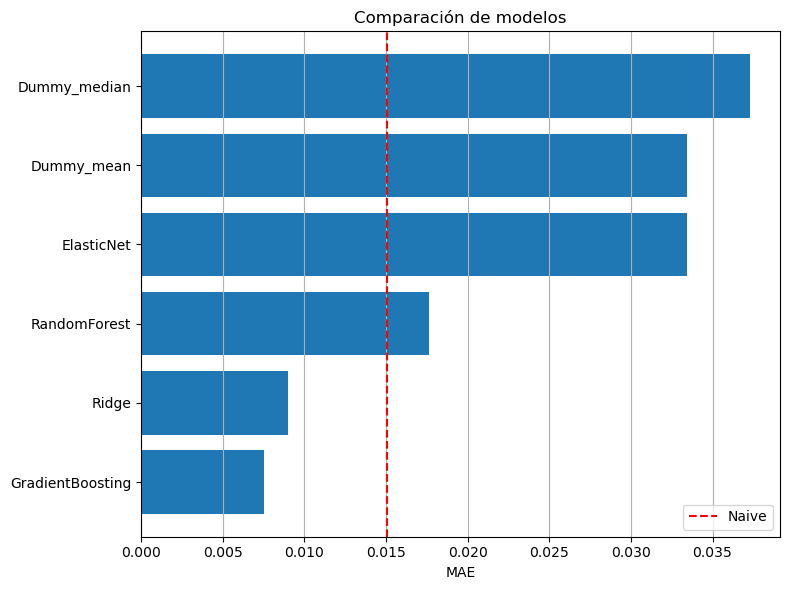

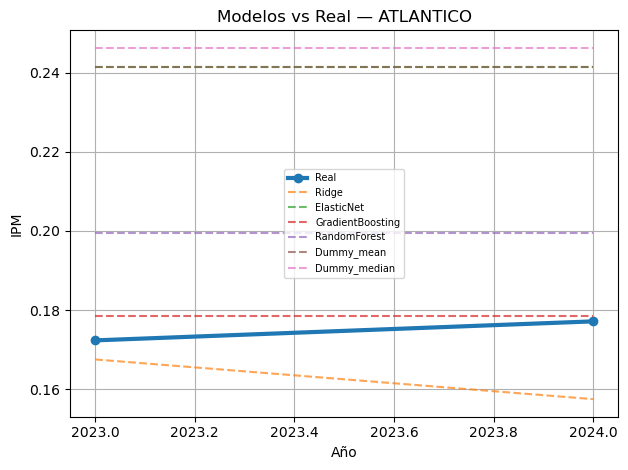

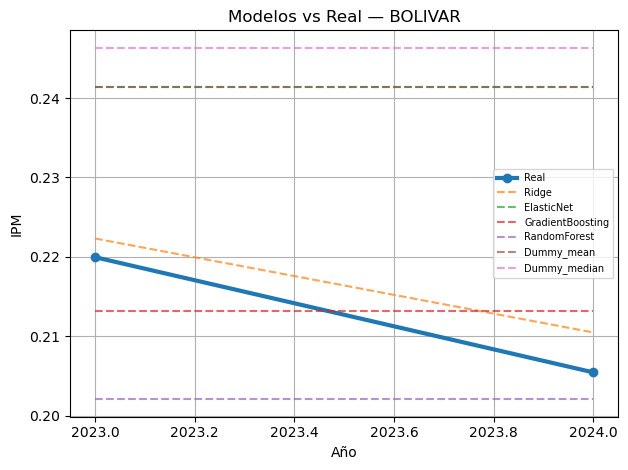

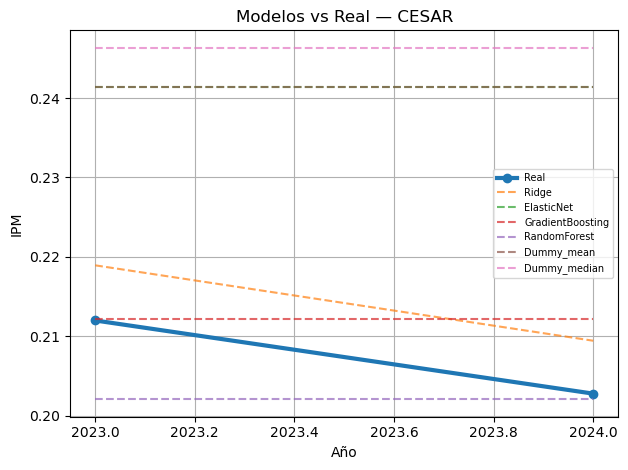

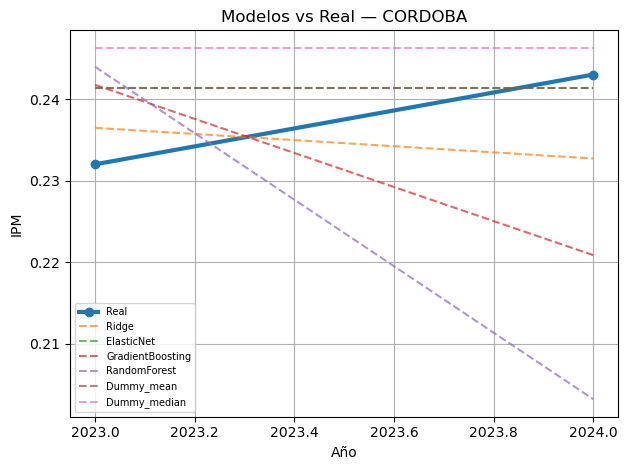

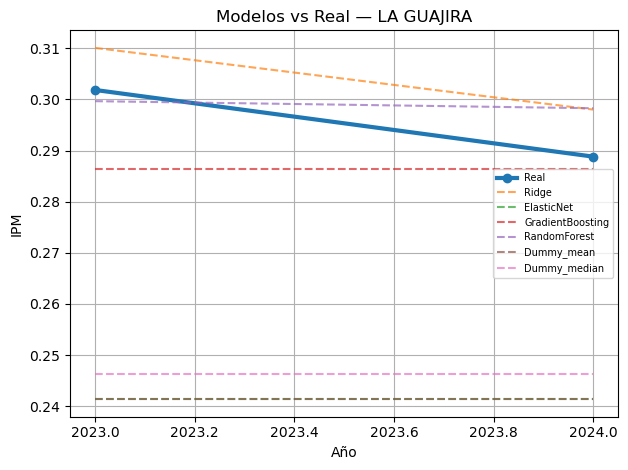

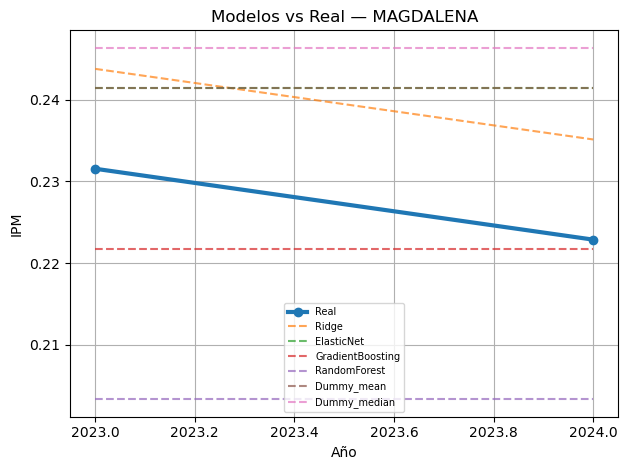

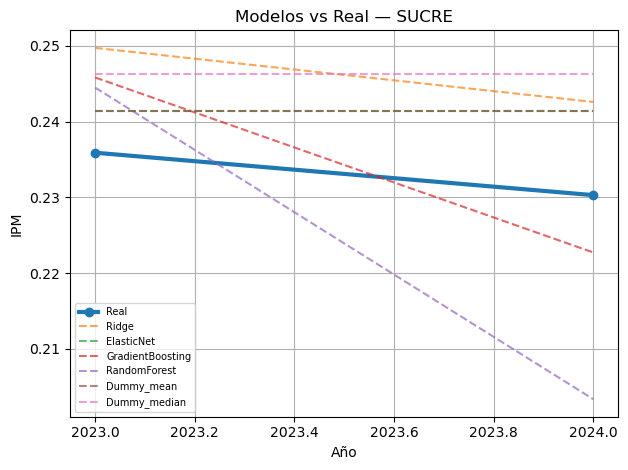

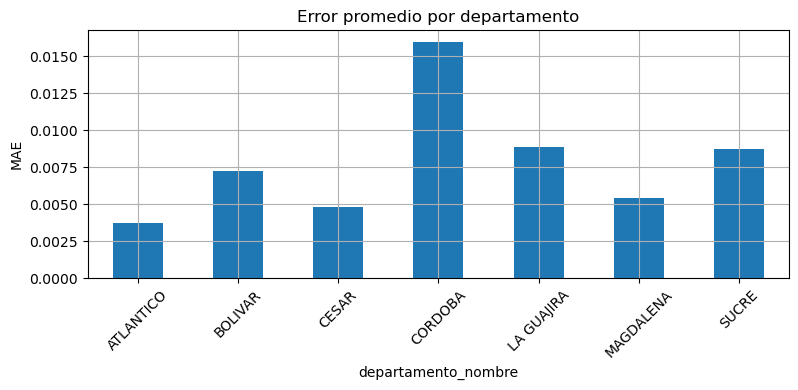

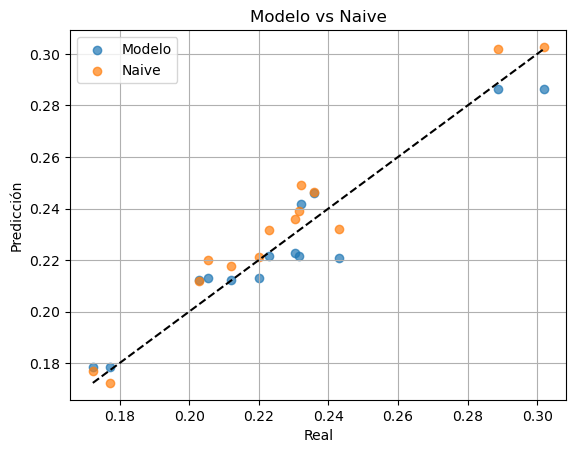

In [177]:
# ==============================
# 11. VISUALIZACIONES (conjunto de prueba) — CORREGIDO
# ==============================

# 🔥 RECONSTRUIR test correctamente (EVITA DESALINEACIÓN)
test = df_model[df_model['año'] > 2022].copy().reset_index(drop=True)

X_test = test[features_num + features_cat]
y_test = test[target]
w_test = test['peso']

# 🔥 predicciones consistentes
best_pred  = best_model.predict(X_test)
naive_pred = X_test['ipm_lag1'].values

# 🔥 sanity check REAL
print("test:", len(test))
print("X_test:", len(X_test))
print("y_test:", len(y_test))
print("best_pred:", len(best_pred))

assert len(test) == len(y_test) == len(best_pred), "❌ Sigue habiendo desalineación"

# ==============================
# GRÁFICAS
# ==============================

# Comparación de MAE entre modelos
plot_model_comparison(results, mae_naive)

# Modelos vs Real por departamento
plot_all_models(test, y_test, results, features_num, features_cat)

# Error promedio por departamento (mejor modelo)
plot_error_depto(test, y_test, best_pred)

# Scatter: modelo vs naive
plot_model_vs_naive(y_test.values, best_pred, naive_pred)

In [178]:
# ==============================
# 11B. EVALUACIÓN MULTI-STEP (REALISTA)
# ==============================

def recursive_forecast(model, df_depto, start_year=2023, end_year=2024):
    df_temp = df_depto.copy()
    preds = []

    for year in range(start_year, end_year + 1):
        df_year = df_temp[df_temp['año'] == year].copy()

        X_year = df_year[features_num + features_cat]
        pred = model.predict(X_year)

        df_temp.loc[df_temp['año'] == year, 'ipm'] = pred
        preds.extend(pred)

    return np.array(preds)

multi_pred = recursive_forecast(best_model, df_model)

y_multi = df_model[df_model['año'].isin([2023, 2024])]['ipm'].values

mae_multi = mean_absolute_error(y_multi, multi_pred)
rmse_multi = np.sqrt(mean_squared_error(y_multi, multi_pred))

print("\nMulti-step Forecast:")
print(f"MAE: {mae_multi:.4f} | RMSE: {rmse_multi:.4f}")


Multi-step Forecast:
MAE: 0.0078 | RMSE: 0.0097


In [179]:
# ==============================
# 12. IMPORTANCIA DE FEATURES (GradientBoosting)
# ==============================
gb_pipe        = results['GradientBoosting']['model']
feature_names  = gb_pipe.named_steps['preprocess'].get_feature_names_out()
importances    = gb_pipe.named_steps['model'].feature_importances_

imp_df = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
)
print(imp_df.to_string())

                               feature  importance
0                        num__ipm_lag1    0.847913
6  cat__departamento_nombre_LA GUAJIRA    0.088573
2   cat__departamento_nombre_ATLANTICO    0.052261
1                           num__trend    0.004115
4       cat__departamento_nombre_CESAR    0.003961
7   cat__departamento_nombre_MAGDALENA    0.002259
8       cat__departamento_nombre_SUCRE    0.000849
5     cat__departamento_nombre_CORDOBA    0.000069
3     cat__departamento_nombre_BOLIVAR    0.000000


## Análisis exploratorio

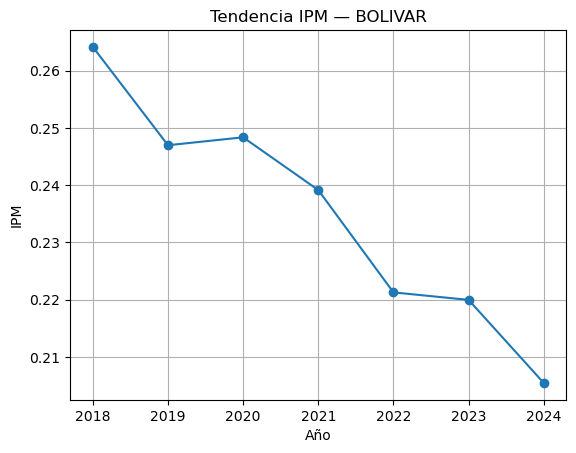

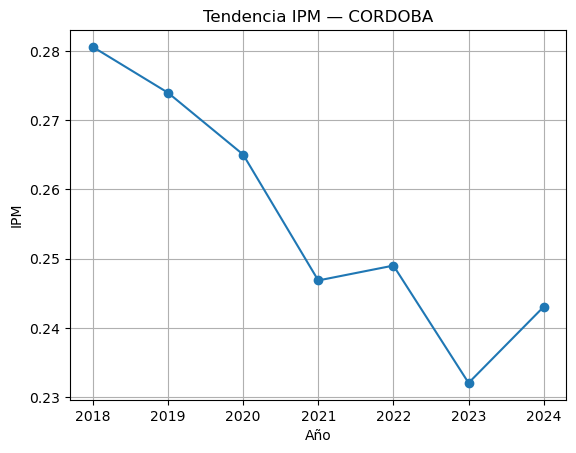

     año       ipm  delta_ipm
7   2018  0.264139        NaN
8   2019  0.246969  -0.017171
9   2020  0.248348   0.001379
10  2021  0.239138  -0.009210
11  2022  0.221259  -0.017878
12  2023  0.219950  -0.001309
13  2024  0.205445  -0.014505


In [180]:
# ==============================
# 13. TENDENCIAS Y VARIACIÓN ANUAL
# ==============================

# Series históricas por departamento
plot_trend(df_depto, 'BOLIVAR')
plot_trend(df_depto, 'CORDOBA')

# Variación anual del IPM
df_depto['delta_ipm'] = df_depto.groupby('departamento_nombre')['ipm'].diff()
print(df_depto[df_depto['departamento_nombre'] == 'BOLIVAR']
      [['año', 'ipm', 'delta_ipm']])

## Predicción 2025

In [181]:
# ==============================
# 14. CONSTRUCCIÓN DE FEATURES PARA 2025 (CORREGIDO)
# ==============================

rows = []
for depto in df_depto['departamento_nombre'].unique():
    sub = df_depto[df_depto['departamento_nombre'] == depto].sort_values('año')

    ipm_yr = sub.set_index('año')['ipm']

    lag1 = ipm_yr.get(2024, np.nan)
    #lag2 = ipm_yr.get(2023, np.nan)

    # trend = siguiente paso temporal
    trend_next = sub.shape[0]

    rows.append({
        'departamento_nombre': depto,
        'ipm_lag1': lag1,
        
        'trend': trend_next,
    })

df_2025_input = pd.DataFrame(rows)

X_2025 = df_2025_input[features_num + features_cat]
pred_2025 = best_model.predict(X_2025)

df_2025_input['ipm_2025_pred'] = pred_2025
df_2025_input['naive_2025'] = df_2025_input['ipm_lag1']
df_2025_input['diff_modelo_naive'] = (
    df_2025_input['ipm_2025_pred'] - df_2025_input['naive_2025']
)

print(df_2025_input[['departamento_nombre', 'ipm_lag1', 'ipm_2025_pred']])

  departamento_nombre  ipm_lag1  ipm_2025_pred
0           ATLANTICO  0.177127       0.178460
1             BOLIVAR  0.205445       0.201908
2               CESAR  0.202766       0.200888
3             CORDOBA  0.243045       0.241100
4          LA GUAJIRA  0.288822       0.286457
5           MAGDALENA  0.222874       0.214361
6               SUCRE  0.230296       0.222731


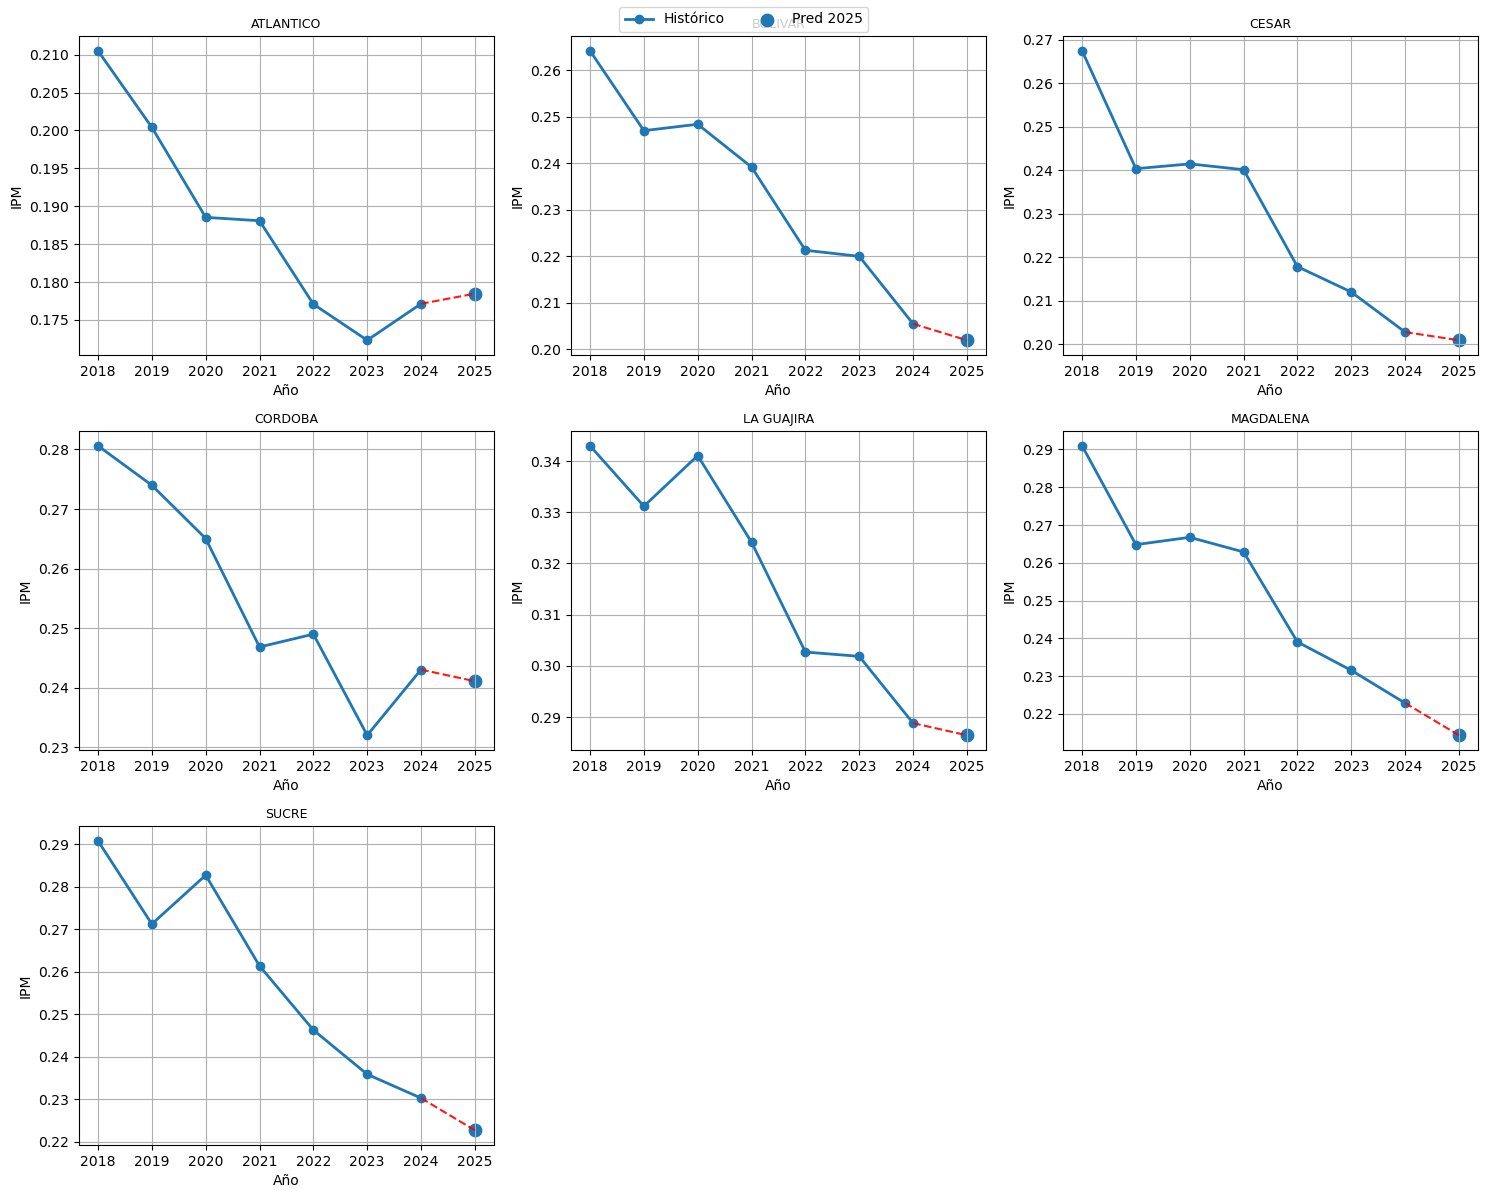

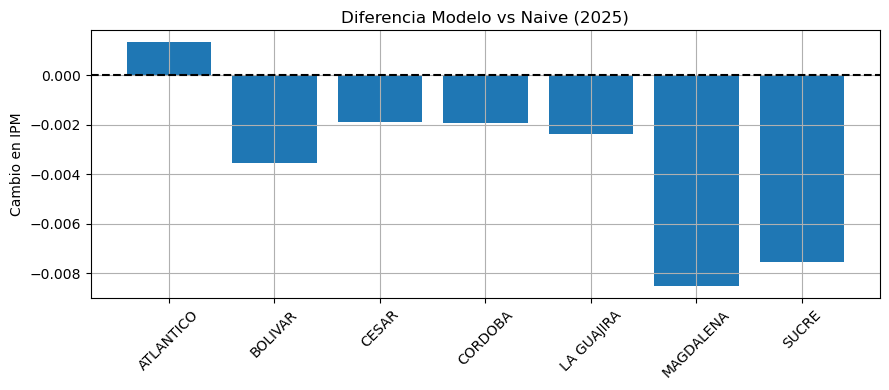

In [182]:
# ==============================
# 15. VISUALIZACIONES DEL FORECAST
# ==============================

# Grid de series históricas + predicción 2025
plot_forecast_grid(df_depto, df_2025_input, n_cols=3)

# Diferencia modelo vs naive por departamento
plt.figure(figsize=(9, 4))
plt.bar(df_2025_input['departamento_nombre'], df_2025_input['diff_modelo_naive'])
plt.axhline(0, linestyle='--', color='k')
plt.title('Diferencia Modelo vs Naive (2025)')
plt.ylabel('Cambio en IPM')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

In [183]:
print("\nTamaño efectivo del panel:")
print(f"Departamentos: {df_model['departamento_nombre'].nunique()}")
print(f"Años: {df_model['año'].nunique()}")
print(f"Observaciones totales: {df_model.shape[0]}")


Tamaño efectivo del panel:
Departamentos: 7
Años: 6
Observaciones totales: 42


In [184]:
# ==============================
# FORECAST ENCADENADO 2025–2026
# ==============================

year_min = int(df_depto['año'].min())

rows = []

for depto in df_depto['departamento_nombre'].unique():
    
    sub = df_depto[df_depto['departamento_nombre'] == depto].sort_values('año')
    ipm_yr = sub.set_index('año')['ipm']
    
    # ==============================
    # BASE: datos reales
    # ==============================
    ipm_2024 = ipm_yr.get(2024)
    ipm_2023 = ipm_yr.get(2023)
    
    # ==============================
    # ---- PREDICCIÓN 2025 ----
    # ==============================
    X_2025 = pd.DataFrame([{
        'departamento_nombre': depto,
        'ipm_lag1': ipm_2024,
        'trend': 2025 - year_min
    }])
    
    pred_2025 = best_model.predict(X_2025)[0]
    
    # ==============================
    # ---- PREDICCIÓN 2026 (encadenado) ----
    # ==============================
    X_2026 = pd.DataFrame([{
        'departamento_nombre': depto,
        'ipm_lag1': pred_2025,  # 🔥 aquí está el encadenamiento
        'trend': 2026 - year_min
    }])
    
    pred_2026 = best_model.predict(X_2026)[0]
    
    # Guardar resultados
    rows.append({
        'departamento_nombre': depto,
        'ipm_2024_real': ipm_2024,
        'ipm_2025_pred': pred_2025,
        'ipm_2026_pred': pred_2026,
        'naive_2025': ipm_2024,
        'naive_2026': pred_2025  # naive encadenado
    })

df_forecast = pd.DataFrame(rows)

print(df_forecast)

  departamento_nombre  ipm_2024_real  ipm_2025_pred  ipm_2026_pred  \
0           ATLANTICO       0.177127       0.178460       0.178460   
1             BOLIVAR       0.205445       0.201908       0.201908   
2               CESAR       0.202766       0.200888       0.200888   
3             CORDOBA       0.243045       0.241100       0.241100   
4          LA GUAJIRA       0.288822       0.286457       0.286457   
5           MAGDALENA       0.222874       0.214361       0.214361   
6               SUCRE       0.230296       0.222731       0.215332   

   naive_2025  naive_2026  
0    0.177127    0.178460  
1    0.205445    0.201908  
2    0.202766    0.200888  
3    0.243045    0.241100  
4    0.288822    0.286457  
5    0.222874    0.214361  
6    0.230296    0.222731  


In [185]:
# ==============================
# 14B. FORECAST ENCADENADO 2025–2026
# ==============================

year_min = int(df_depto['año'].min())

rows = []

for depto in df_depto['departamento_nombre'].unique():
    
    sub = df_depto[df_depto['departamento_nombre'] == depto].sort_values('año')
    ipm_yr = sub.set_index('año')['ipm']
    
    ipm_2024 = ipm_yr.get(2024)
    
    # ---- 2025 ----
    X_2025 = pd.DataFrame([{
        'departamento_nombre': depto,
        'ipm_lag1': ipm_2024,
        'trend': 2025 - year_min
    }])
    
    pred_2025 = best_model.predict(X_2025)[0]
    
    # ---- 2026 (encadenado) ----
    X_2026 = pd.DataFrame([{
        'departamento_nombre': depto,
        'ipm_lag1': pred_2025,
        'trend': 2026 - year_min
    }])
    
    pred_2026 = best_model.predict(X_2026)[0]
    
    rows.append({
        'departamento_nombre': depto,
        'ipm_2024': ipm_2024,
        'ipm_2025_pred': pred_2025,
        'ipm_2026_pred': pred_2026,
        'naive_2025': ipm_2024,
        'naive_2026': pred_2025
    })

df_forecast = pd.DataFrame(rows)

In [186]:
def plot_forecast_2years(df_depto, df_forecast, n_cols=3):
    deptos = df_depto['departamento_nombre'].unique()
    n_rows = int(np.ceil(len(deptos) / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()

    for i, depto in enumerate(deptos):
        ax = axes[i]
        
        hist = df_depto[df_depto['departamento_nombre'] == depto]
        pred = df_forecast[df_forecast['departamento_nombre'] == depto]

        # histórico
        ax.plot(hist['año'], hist['ipm'], marker='o', linewidth=2, label='Histórico')

        if not pred.empty:
            ipm_2024 = pred['ipm_2024'].values[0]
            ipm_2025 = pred['ipm_2025_pred'].values[0]
            ipm_2026 = pred['ipm_2026_pred'].values[0]

            # puntos forecast
            ax.scatter(2025, ipm_2025, s=80, label='Pred 2025')
            ax.scatter(2026, ipm_2026, s=80, label='Pred 2026')

            # líneas encadenadas
            ax.plot([2024, 2025], [ipm_2024, ipm_2025],
                    linestyle='--', color='red', alpha=0.9)
            ax.plot([2025, 2026], [ipm_2025, ipm_2026],
                    linestyle='--', color='red', alpha=0.9)

        ax.set_title(depto, fontsize=9)
        ax.set_xlabel('Año')
        ax.set_ylabel('IPM')
        ax.grid()

    # limpiar ejes vacíos
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4)

    plt.tight_layout()
    plt.show()

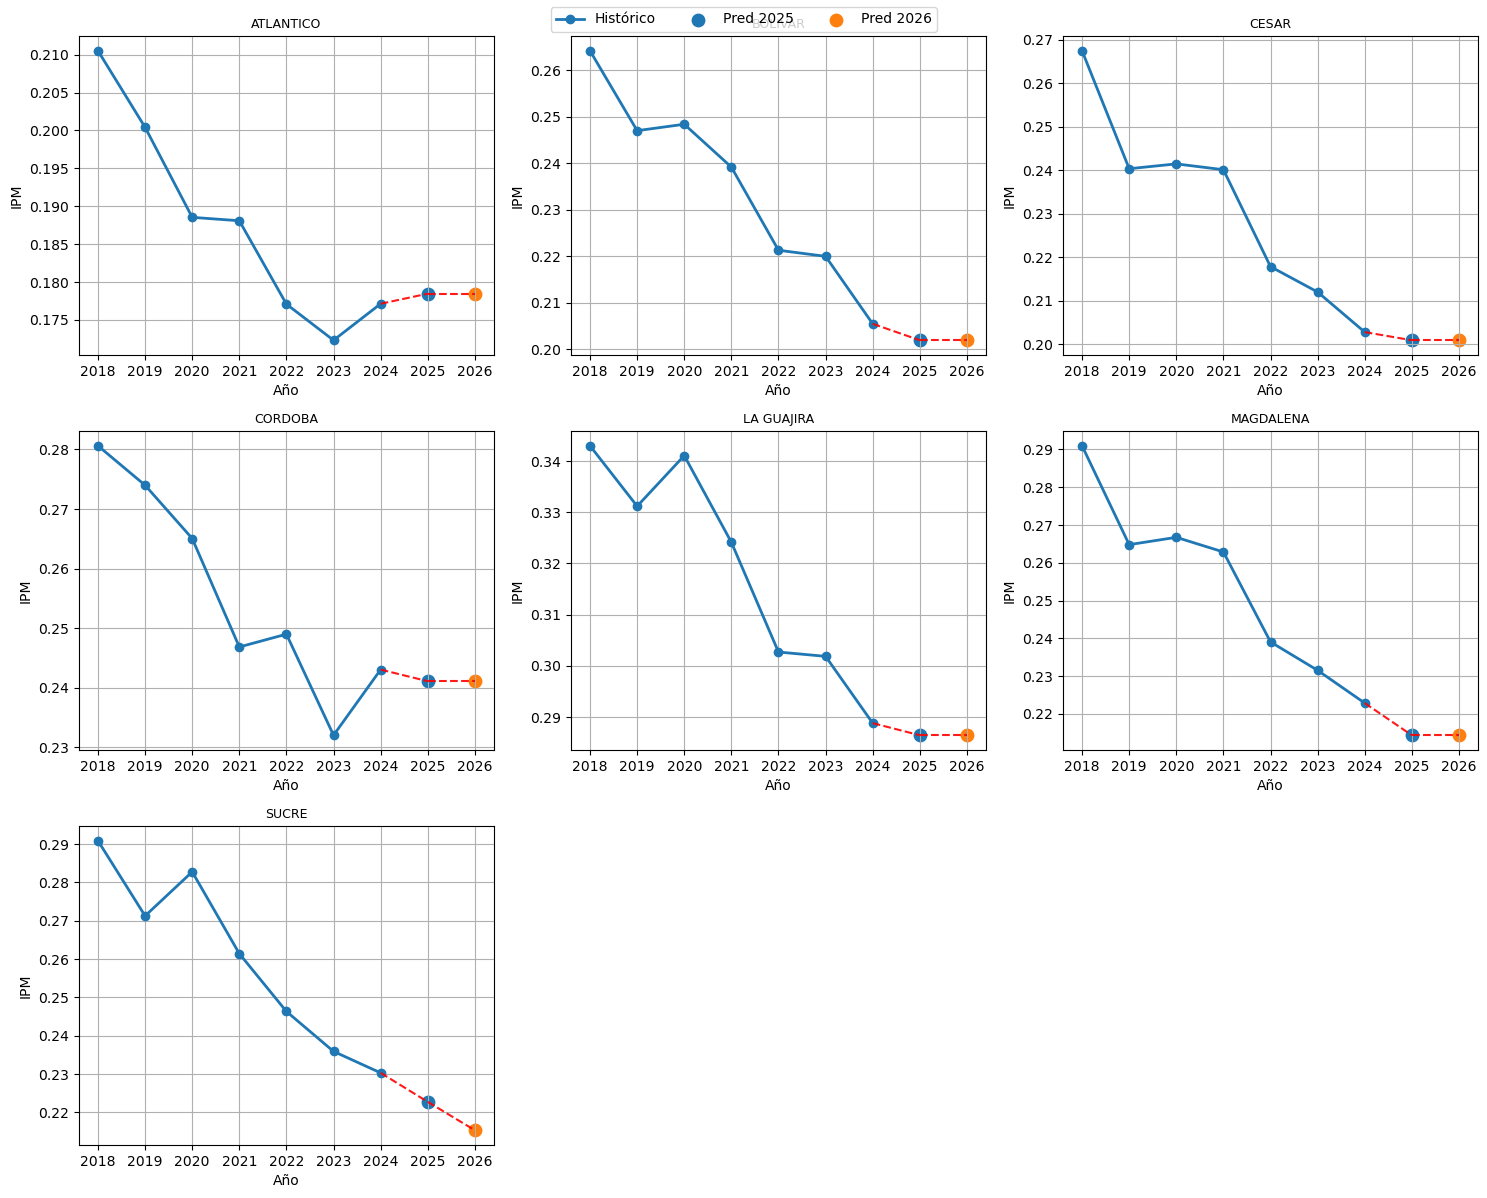

In [187]:
# ==============================
# 15B. VISUALIZACIÓN FORECAST 2025–2026
# ==============================

plot_forecast_2years(df_depto, df_forecast, n_cols=3)